<a href="https://colab.research.google.com/github/nicolagherardi/AI_course_test/blob/main/Assignment_2_AH2170_Gherardi_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt

# Import the dataset
df = pd.read_csv("AH2170_HT17_CSII_Travel_Times.csv")
df.head()

,Route,Year,Month,Day,Time,Segment Length,Travel Time
0,E3:1,2005,4,4,22635,1177,143
1,D8:1,2005,4,4,22635,604,53
2,D7:2,2005,4,4,22635,625,53
3,D6:2,2005,4,4,22635,1329,196
4,B4:2,2005,4,4,22635,997,71


# Part A

In [ ]:
df_A = df.copy()
df_A.nunique()

,0
Route,7
Year,1
Month,1
Day,14
Time,24
Segment Length,7
Travel Time,411


In [ ]:
df.shape

(1316, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1316 entries, 0 to 1315
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Route           1316 non-null   object
 1   Year            1316 non-null   int64 
 2   Month           1316 non-null   int64 
 3   Day             1316 non-null   int64 
 4   Time            1316 non-null   int64 
 5   Segment Length  1316 non-null   int64 
 6   Travel Time     1316 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 72.1+ KB


I want to remove year and month since they are not explanatory (1 unique value)

In [ ]:
df_A = df_A.drop(columns=['Year', 'Month'])
df_A = df_A[((df_A['Day'] >= 4) & (df_A['Day'] <= 8)) | ((df_A['Day'] >= 11) & (df_A['Day'] <= 15))]
df_A

,Route,Day,Time,Segment Length,Travel Time
0,E3:1,4,22635,1177,143
1,D8:1,4,22635,604,53
2,D7:2,4,22635,625,53
3,D6:2,4,22635,1329,196
4,B4:2,4,22635,997,71
...,...,...,...,...,...
935,E3:1,15,34335,1177,253
936,D8:1,15,34335,604,225
937,D7:2,15,34335,625,90
938,D6:2,15,34335,1329,215


In [ ]:
import pandas as pd

# 1. Create 'Unique_Time_Period' column in df_A and pivot
df_A['Unique_Time_Period'] = df_A['Day'].astype(str) + '_' + df_A['Time'].astype(str)

# Pivot the DataFrame to have routes as columns and travel times as values
df_pivot = df_A.pivot_table(index='Unique_Time_Period', columns='Route', values='Travel Time')
df_pivot = df_pivot.reset_index()
df_pivot.columns.name = None # Remove the 'Route' name from columns axis for cleaner column names

# 2. Prepare base DataFrame, keeping NaNs from pivot_table
df_base_cleaned = df_pivot.copy() # Do not drop NaNs here as requested

# 3. Reconstruct Day and Time_seconds columns from Unique_Time_Period
df_base_cleaned[['Day_str', 'Time_str']] = df_base_cleaned['Unique_Time_Period'].str.split('_', expand=True)
df_base_cleaned['Day'] = df_base_cleaned['Day_str'].astype(int)
df_base_cleaned['Time_seconds'] = df_base_cleaned['Time_str'].astype(int)

# Assuming Year=2005 and Month=4 (as per original context)
fixed_year = 2005
fixed_month = 4

# Create complete datetime objects
df_base_cleaned['datetime'] = pd.to_datetime(f'{fixed_year}-{fixed_month}-01') + \
                               (df_base_cleaned['Day'] - 1).astype('timedelta64[D]') + \
                               pd.to_timedelta(df_base_cleaned['Time_seconds'], unit='s')

# Sort by datetime to ensure correct temporal sequence
df_base_cleaned = df_base_cleaned.sort_values(by='datetime').reset_index(drop=True)

print("Initial DataFrame with datetime column and sorted (first 5 rows):")
display(df_base_cleaned.head())
print(df_base_cleaned.shape)

Initial DataFrame with datetime column and sorted (first 5 rows):


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,Day_str,Time_str,Day,Time_seconds,datetime
0,4_22635,71.0,NaN,196.0,53.0,53.0,NaN,143.0,4,22635,4,22635,2005-04-04 06:17:15
1,4_23535,76.0,191.0,130.0,50.0,51.0,87.0,118.0,4,23535,4,23535,2005-04-04 06:32:15
2,4_24435,65.0,230.0,144.0,66.0,39.0,801.0,139.0,4,24435,4,24435,2005-04-04 06:47:15
3,4_25335,136.0,265.0,144.0,64.0,179.0,438.0,107.0,4,25335,4,25335,2005-04-04 07:02:15
4,4_26235,128.0,209.0,202.0,67.0,185.0,144.0,152.0,4,26235,4,26235,2005-04-04 07:17:15


(140, 13)


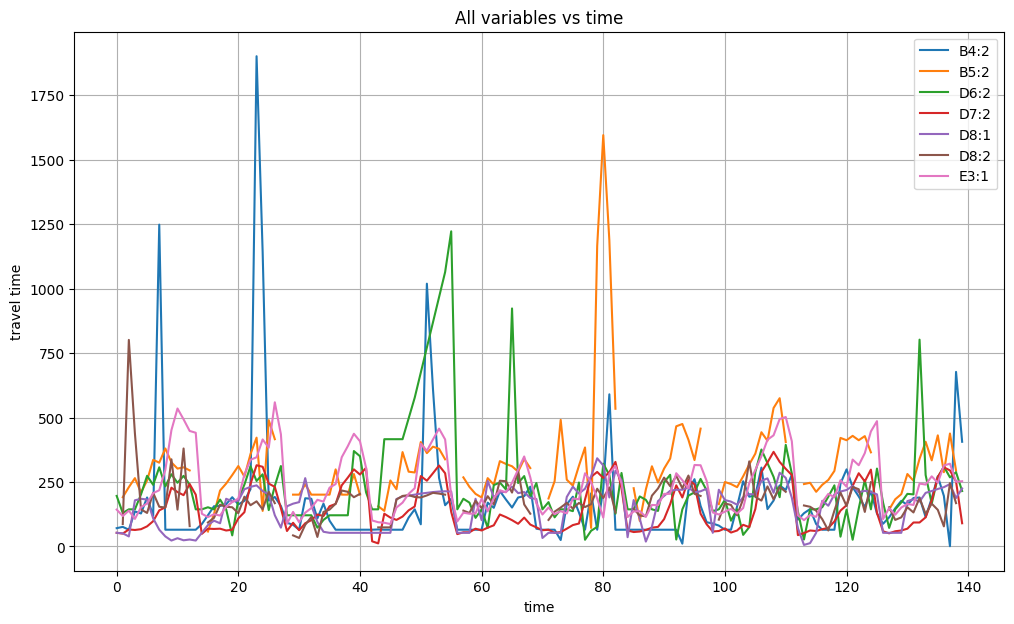

In [ ]:
import matplotlib.pyplot as plt

# List columns that contain non-numeric data or metadata
# that should not be plotted directly as time series along with other numerical values.
columns_to_exclude = [
    'Unique_Time_Period', 'Day_str', 'Time_str', 'Day', 'Time_seconds', 'datetime'
]

# Filter out columns to exclude from plotting. `errors='ignore'` prevents errors if a column does not exist.
df_plot = df_base_cleaned.drop(columns=columns_to_exclude, errors='ignore')

# Plot the remaining numerical columns
df_plot.plot(figsize=(12, 7))
plt.title("All variables vs time")
plt.xlabel("time")
plt.ylabel("travel time")
plt.grid(True)
plt.show()

In [ ]:
# 4. Generate time-based lagged variables (only lag1 as requested)

dependent_variable = 'D7:2'
# List of variables to lag (excluding 'Unique_Time_Period', 'datetime', and the dependent variable)
candidates_for_lagging = [col for col in df_base_cleaned.columns if col not in ['Unique_Time_Period', 'datetime', 'Day_str', 'Time_str', 'Day', 'Time_seconds', dependent_variable]]

# Initialize the final DataFrame for the model
df_model_time_lagged = df_base_cleaned.copy()

all_new_lagged_cols = []

# Only generate lag1 with fixed suffix '_lag1' as requested
lag_suffix = '_lag1'
lag_duration = pd.Timedelta(minutes=15) # Assuming a 15-minute interval for lag1

for col in candidates_for_lagging:
    new_col_name = f'{col}{lag_suffix}'

    # Create a temporary DataFrame with 'datetime' and the current variable 'col'
    # This DataFrame represents the values that will become lags
    lag_values_df = df_base_cleaned[['datetime', col]].copy()

    # Create a 'lagged_timestamp' column in this temp_df
    # This lagged_timestamp represents the 'datetime' at which these values will *act* as lags
    lag_values_df['lagged_timestamp'] = lag_values_df['datetime'] + lag_duration

    # Rename the original column to the new lagged column name for the merge
    lag_values_df = lag_values_df.rename(columns={col: new_col_name})

    # Perform a left merge. We want to attach the lagged value (new_col_name)
    # to the main dataframe (df_model_time_lagged) where its 'datetime'
    # matches the 'lagged_timestamp' from lag_values_df.
    df_model_time_lagged = pd.merge(
        df_model_time_lagged,
        lag_values_df[['lagged_timestamp', new_col_name]],
        left_on='datetime',
        right_on='lagged_timestamp',
        how='left'
    )
    # Drop the temporary 'lagged_timestamp' column from the merged result
    df_model_time_lagged = df_model_time_lagged.drop(columns=['lagged_timestamp'])

    all_new_lagged_cols.append(new_col_name)

# --- Final DataFrame Preparation ---
# Remove temporary columns
columns_to_drop = ['Day_str', 'Time_str', 'Day', 'Time_seconds', 'datetime']
df_final_with_lags = df_model_time_lagged.drop(columns=columns_to_drop)

# The final dropna removes rows where lagged variables or the dependent variable are NaN
# (e.g., the first slots of each day for which no lag exists, or original NaNs from pivot_table)
full_independent_candidates_list = candidates_for_lagging + all_new_lagged_cols
df_final_with_lags = df_final_with_lags.dropna(subset=[dependent_variable] + full_independent_candidates_list)

print(f"\nShape of the final DataFrame after adding time-based lagged variables and removing NaNs: {df_final_with_lags.shape}")
print("\nFinal DataFrame with lagged variables (first 10 rows):")
display(df_final_with_lags.head(10))


Shape of the final DataFrame after adding time-based lagged variables and removing NaNs: (90, 14)

Final DataFrame with lagged variables (first 10 rows):


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,B4:2_lag1,B5:2_lag1,D6:2_lag1,D8:1_lag1,D8:2_lag1,E3:1_lag1
2,4_24435,65.0,230.0,144.0,66.0,39.0,801.0,139.0,76.0,191.0,130.0,51.0,87.0,118.0
3,4_25335,136.0,265.0,144.0,64.0,179.0,438.0,107.0,65.0,230.0,144.0,39.0,801.0,139.0
4,4_26235,128.0,209.0,202.0,67.0,185.0,144.0,152.0,136.0,265.0,144.0,179.0,438.0,107.0
5,4_27135,190.0,256.0,274.0,78.0,182.0,130.0,167.0,128.0,209.0,202.0,185.0,144.0,152.0
6,4_28035,119.0,336.0,239.0,98.0,109.0,208.0,207.0,190.0,256.0,274.0,182.0,130.0,167.0
7,4_28935,1248.0,325.0,307.0,140.0,65.0,154.0,218.0,119.0,336.0,239.0,109.0,208.0,207.0
8,4_29835,65.0,380.0,233.0,152.0,39.0,151.0,297.0,1248.0,325.0,307.0,65.0,154.0,218.0
9,4_30735,65.0,326.0,280.0,228.0,23.0,338.0,451.0,65.0,380.0,233.0,39.0,151.0,297.0
10,4_31635,65.0,302.0,247.0,211.0,32.0,143.0,535.0,65.0,326.0,280.0,23.0,338.0,451.0
11,4_32535,65.0,307.0,274.0,199.0,24.0,380.0,493.0,65.0,302.0,247.0,32.0,143.0,535.0


In [ ]:
# The following code was used to identify and remove outliers:
# from matplotlib.collections import TriMesh
# from scipy import stats

# threshold = 3
# df_final_with_lags['zscore']=stats.zscore(df_final_with_lags['E3:1']) #check on the future most important variable
# outliers = df_final_with_lags[abs(df_final_with_lags['zscore']) > threshold]

# print("The number of outliers with threshold", threshold, "is", len(outliers))
# print("\n", outliers)

# 1st option
We train the first model using only the travel times on OTHER links at the same time slot

Shape of DataFrame for non-lagged model: (120, 13)

Generating scatter plots for 'D7:2' against other segments...


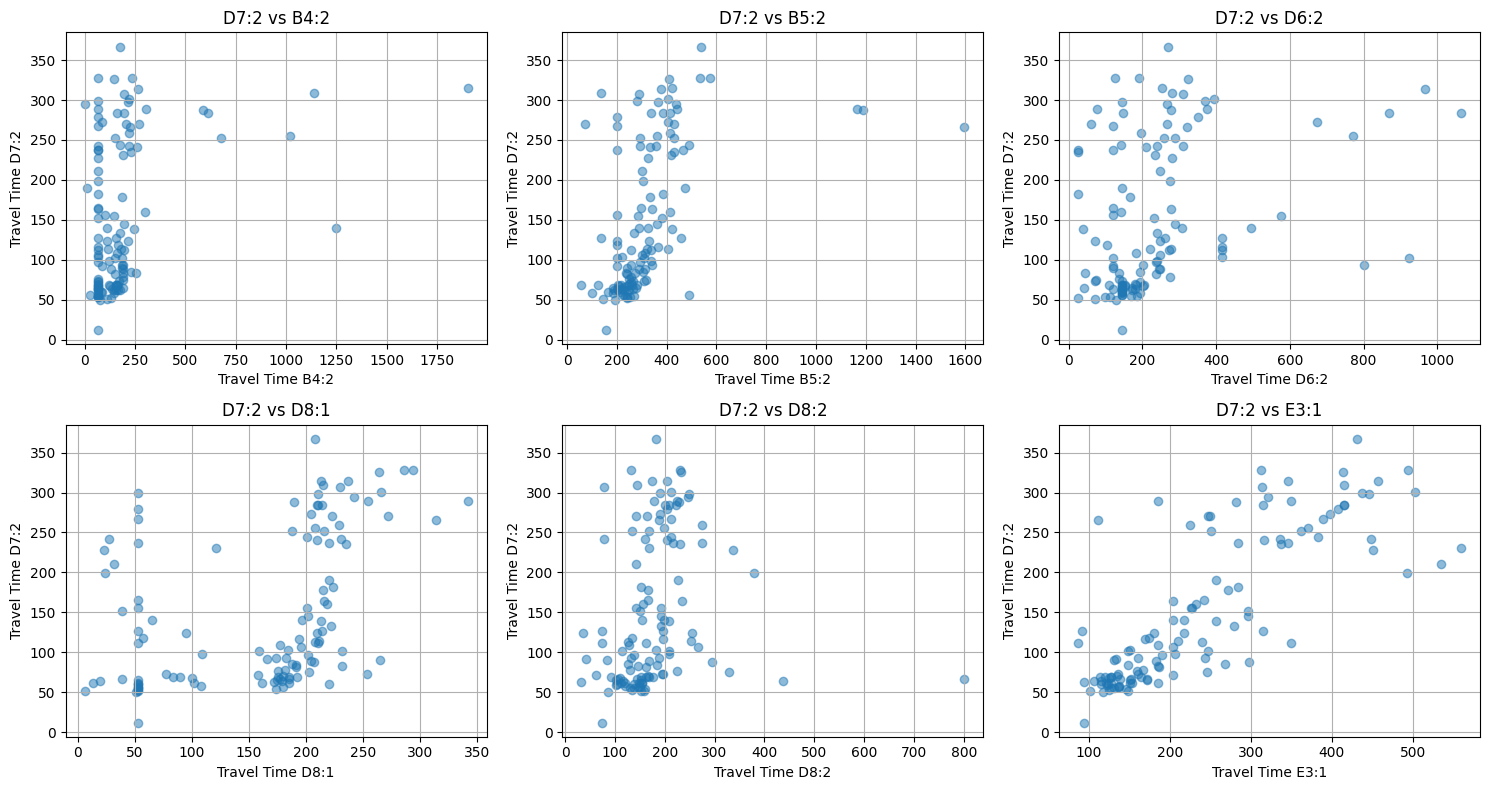

In [ ]:
# Identify the dependent variable (Y) and potential independent variables (X)
dependent_variable = 'D7:2'

# Filter out lagged variables based on their suffix as requested by 'non usare variabili lag'
independent_variables_candidates = [col for col in df_base_cleaned.columns
                                    if col not in ['Unique_Time_Period', dependent_variable, 'Day_str', 'Time_str', 'Day', 'Time_seconds', 'datetime']
                                    and not col.endswith('_lag1')]

# Create a specific DataFrame for the non-lagged model
# This DataFrame will only drop NaNs from the dependent variable and the non-lagged candidates.
# It starts from df_base_cleaned which has original NaNs but not NaNs from lag generation.
df_for_non_lagged_model = df_base_cleaned.dropna(subset=[dependent_variable] + independent_variables_candidates).copy()

print(f"Shape of DataFrame for non-lagged model: {df_for_non_lagged_model.shape}")

if not independent_variables_candidates:
    print("No other segments found to use as independent variables.")
else:
    # --- Plotting to identify promising variables ---
    print(f"\nGenerating scatter plots for '{dependent_variable}' against other segments...")

    num_plots = len(independent_variables_candidates)
    # Determine number of rows and columns for subplots, max 3 columns per row
    cols_per_row = 3
    rows = (num_plots + cols_per_row - 1) // cols_per_row

    plt.figure(figsize=(5 * cols_per_row, 4 * rows)) # Adjust figure size dynamically
    for i, col in enumerate(independent_variables_candidates):
        plt.subplot(rows, cols_per_row, i + 1)
        # Use df_for_non_lagged_model for plotting
        plt.scatter(df_for_non_lagged_model[col], df_for_non_lagged_model[dependent_variable], alpha=0.5)
        plt.title(f'{dependent_variable} vs {col}')
        plt.xlabel(f'Travel Time {col}')
        plt.ylabel(f'Travel Time {dependent_variable}')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

The most probable candidate is E3:1, but also B5:2, D6:2, D8:1 and D8:2 can be possible regressors.

In [ ]:
import statsmodels.api as sm

def forward_stepwise_selection(data, dependent_var, candidate_vars, p_threshold=0.05):

    selected_vars = []
    remaining_vars = list(candidate_vars)

    while remaining_vars:
        best_p_value = p_threshold + 0.01 # Initialize with a value higher than threshold
        best_new_var = None

        for var in remaining_vars:
            current_vars = selected_vars + [var]
            # Fix: Changed current_var_names to current_vars
            X = sm.add_constant(data[current_vars])
            Y = data[dependent_var]

            try:
                model = sm.OLS(Y, X).fit()
                # Check if the variable is in the pvalues. This can be tricky if a variable
                # is perfectly collinear with existing variables. In such cases, statsmodels
                # might drop it or assign a NaN p-value.
                if var in model.pvalues:
                    new_var_p_value = model.pvalues[var]
                else:
                    # If the variable is not in pvalues (e.g., dropped due to collinearity), consider it non-significant
                    new_var_p_value = 1.0 # Or use a value > p_threshold

                if new_var_p_value < best_p_value:
                    best_p_value = new_var_p_value
                    best_new_var = var
            except Exception as e:
                # Handle cases where model fitting might fail (e.g., due to perfect multicollinearity for small samples)
                print(f"Warning: Could not fit model with {current_vars}. Error: {e}")
                continue

        if best_new_var and best_p_value < p_threshold:
            selected_vars.append(best_new_var)
            remaining_vars.remove(best_new_var)
            print(f"Added '{best_new_var}' to the model (p-value: {best_p_value:.4f})")
        else:
            break # No more variables to add that meet the significance criterion

    return selected_vars


# Define Y using df_for_non_lagged_model
Y = df_for_non_lagged_model[dependent_variable]

# Define X_candidates to include all non-dependent variables from df_for_non_lagged_model
# These candidates are already filtered to exclude lagged variables in ZjlCQsK_DPFj
X_candidates = independent_variables_candidates

# Select independent variables using forward stepwise selection
print(f"\nPerforming Forward Stepwise Selection for '{dependent_variable}' (excluding lagged variables)...")
selected_X_cols = forward_stepwise_selection(df_for_non_lagged_model, dependent_variable, X_candidates, p_threshold=0.05)

if not selected_X_cols:
    print("No suitable independent variables found by stepwise selection for the given p-threshold.")
else:
    X = df_for_non_lagged_model[selected_X_cols]

    # Add a constant to the independent variables for statsmodels
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(Y, X)
    results = model.fit()

    # Print the regression results
    print("\nRegression Results (Forward Stepwise Selection):")
    print(results.summary())


Performing Forward Stepwise Selection for 'D7:2' (excluding lagged variables)...
Added 'E3:1' to the model (p-value: 0.0000)
Added 'B5:2' to the model (p-value: 0.0000)
Added 'D8:1' to the model (p-value: 0.0060)
Added 'B4:2' to the model (p-value: 0.0222)

Regression Results (Forward Stepwise Selection):
                            OLS Regression Results                            
Dep. Variable:                   D7:2   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     94.11
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.42e-35
Time:                        16:28:58   Log-Likelihood:                -626.76
No. Observations:                 120   AIC:                             1264.
Df Residuals:                     115   BIC:                             1277.
Df Model:                           4                       

In [ ]:
# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Filter out actual zero values to avoid division by zero or infinite MAPE
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask): # If all y_true are zero, MAPE is undefined or 0 if y_pred are also 0
        return np.nan # Return NaN as MAPE is not meaningful in this case
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# MAPE for Option 1
y_A_observed_option1 = df_for_non_lagged_model[dependent_variable]
y_A_forecast_option1 = results.predict(X)
mape_A_option1 = mean_absolute_percentage_error(y_A_observed_option1, y_A_forecast_option1)
print(f"Model 1 (Non-Lagged) - Training Data: MAPE = {mape_A_option1:.2f}%")

Model 1 (Non-Lagged) - Training Data: MAPE = 27.57%


Assumptions checking on residuals:

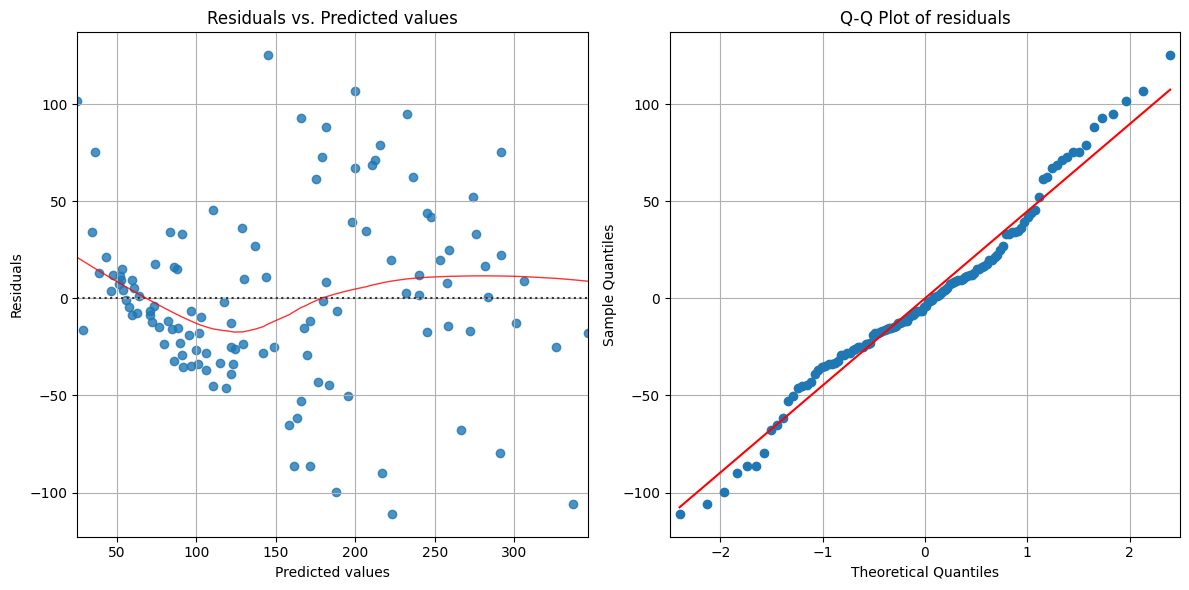


Residuals vs. independent selected variables:


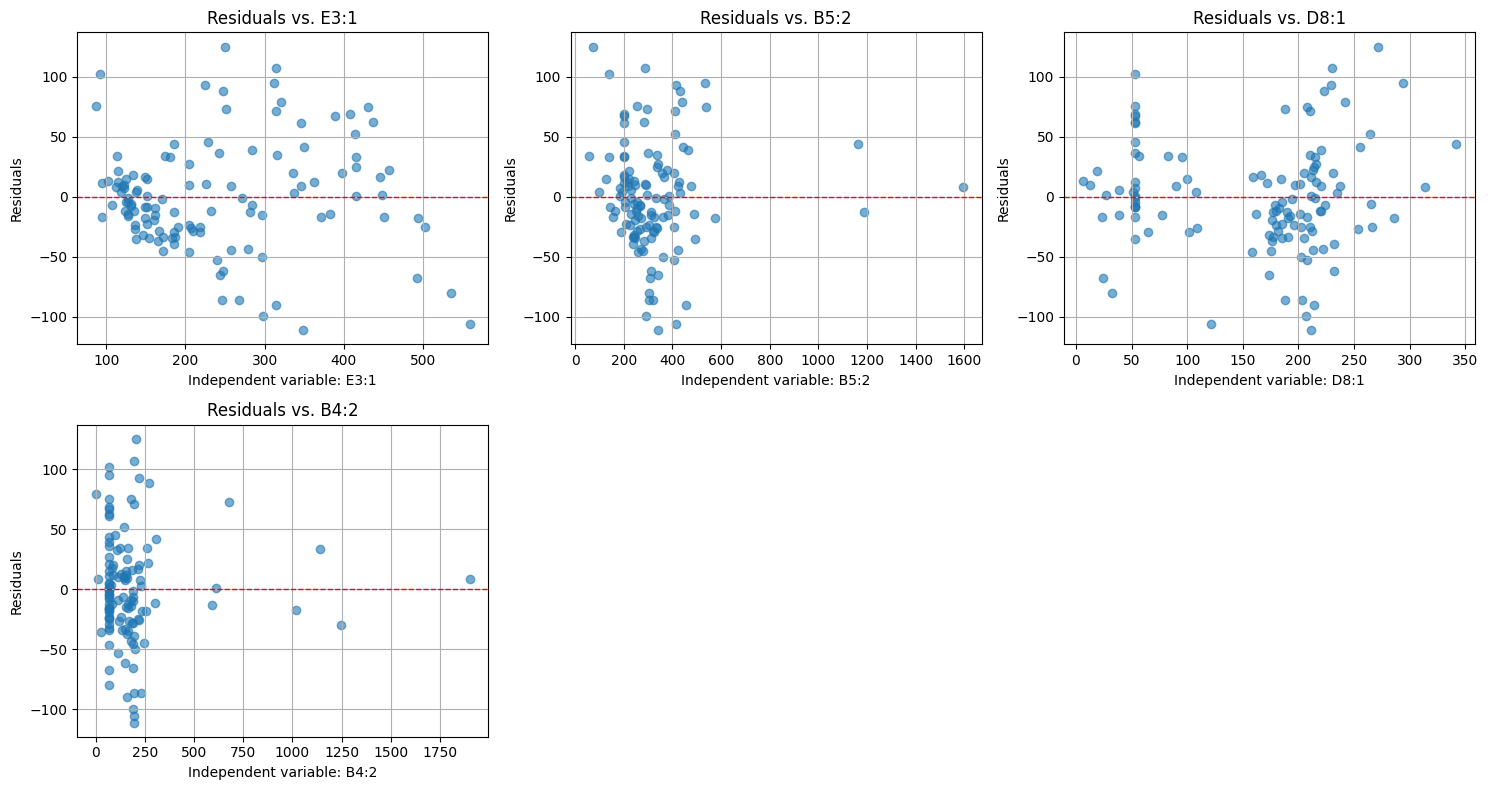

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Residuals vs. Fitted Values Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted values')
plt.grid(True)

# 2. Normal Q-Q Plot of Residuals
plt.subplot(1, 2, 2)
sm.qqplot(results.resid, line='s', ax=plt.gca())
plt.title('Q-Q Plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Residuals vs. Independent Variables Plots
print("\nResiduals vs. independent selected variables:")
# 'X' contains the independent variables plus the constant. We need to exclude the 'const'
X_vars = X.drop(columns='const', errors='ignore')

num_plots = len(X_vars.columns)
cols_per_row = 3
rows = (num_plots + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(5 * cols_per_row, 4 * rows))
for i, col in enumerate(X_vars.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.scatter(X_vars[col], results.resid, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=1)
    plt.xlabel(f'Independent variable: {col}')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs. {col}')
    plt.grid(True)
plt.tight_layout()
plt.show()


--- Assumptions checking on residuals ---

1. Normality:
   Shapiro-Wilk Test: Statistic=0.978, p-value=0.049
   (The p-value is less than 0.05, we reject the null hypothesis of normality.)

2. Independence (Absence of Autocorrelation):


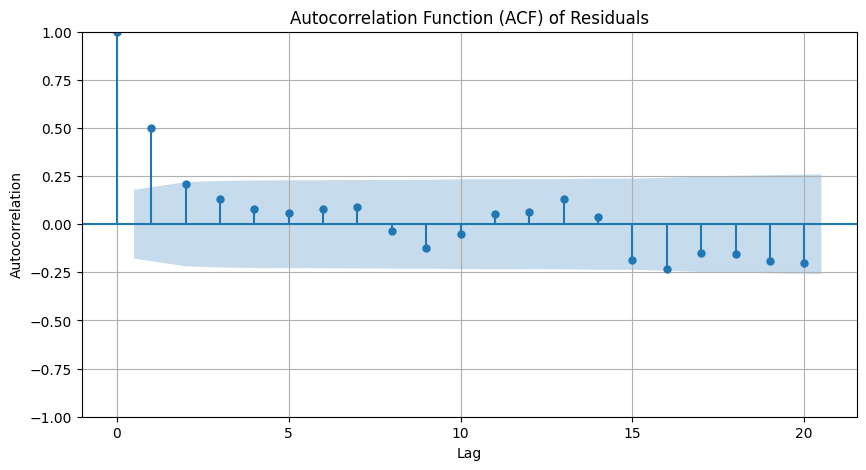

   Ljung-Box Test (p-values for lags 1, 5, 10):
 1     3.444001e-08
5     2.113168e-07
10    3.803088e-06
Name: lb_pvalue, dtype: float64
   (For lag 1, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)
   (For lag 5, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)
   (For lag 10, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)


In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

residuals = results.resid

print("\n--- Assumptions checking on residuals ---")

# 1. Normality of Residuals
print("\n1. Normality:")
# Shapiro-Wilk Test (for small samples, N < 5000)
shapiro_test = stats.shapiro(residuals)
print(f"   Shapiro-Wilk Test: Statistic={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue > 0.05:
    print("   (The p-value is greater than 0.05, we cannot reject the null hypothesis of normality.)")
else:
    print("   (The p-value is less than 0.05, we reject the null hypothesis of normality.)")

# 2. Independence of Residuals (Absence of Autocorrelation)
print("\n2. Independence (Absence of Autocorrelation):")
# Autocorrelation Function (ACF) Plot
plt.figure(figsize=(10, 5))
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Ljung-Box Test
# The Ljung-Box test checks if autocorrelations for a time series are different from zero for a number of lags.
# 'lb_pvalue' is the p-value, 'lb_stat' is the test statistic.
ljungbox_test = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print("   Ljung-Box Test (p-values for lags 1, 5, 10):\n", ljungbox_test['lb_pvalue'])
for lag, pval in ljungbox_test['lb_pvalue'].items():
    if pval > 0.05:
        print(f"   (For lag {lag}, p-value {pval:.3f} > 0.05, no evidence of autocorrelation.)")
    else:
        print(f"   (For lag {lag}, p-value {pval:.3f} <= 0.05, the null hypothesis of no autocorrelation is rejected.)")

# 2nd option
For the second option I also considered the "time travel" at lag 1.

In [ ]:
import statsmodels.api as sm

Y = df_final_with_lags[dependent_variable]

# Define X_candidates to include ALL non-dependent variables from df_final_with_lags,
# including both original and lagged variables.
X_candidates_with_lags = full_independent_candidates_list

print(f"\nPerforming Forward Stepwise Selection for '{dependent_variable}' (including lagged variables)...\n")
selected_X_cols_with_lags = forward_stepwise_selection(df_final_with_lags, dependent_variable, X_candidates_with_lags, p_threshold=0.05)

if not selected_X_cols_with_lags:
    print("No suitable independent variables (including lagged) found by stepwise selection for the given p-threshold.")
else:
    X_with_lags = df_final_with_lags[selected_X_cols_with_lags]

    # Add a constant to the independent variables for statsmodels
    X_with_lags = sm.add_constant(X_with_lags)

    # Fit the OLS model
    model_with_lags = sm.OLS(Y, X_with_lags)
    results_with_lags = model_with_lags.fit()

    # Print the regression results
    print("\nRegression Results (Forward Stepwise Selection with Lagged Variables):")
    print(results_with_lags.summary())


Performing Forward Stepwise Selection for 'D7:2' (including lagged variables)...

Added 'E3:1' to the model (p-value: 0.0000)
Added 'B5:2' to the model (p-value: 0.0000)
Added 'B4:2' to the model (p-value: 0.0133)
Added 'D8:1' to the model (p-value: 0.0398)

Regression Results (Forward Stepwise Selection with Lagged Variables):
                            OLS Regression Results                            
Dep. Variable:                   D7:2   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     67.37
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.46e-25
Time:                        16:33:54   Log-Likelihood:                -472.84
No. Observations:                  90   AIC:                             955.7
Df Residuals:                      85   BIC:                             968.2
Df Model:                           4

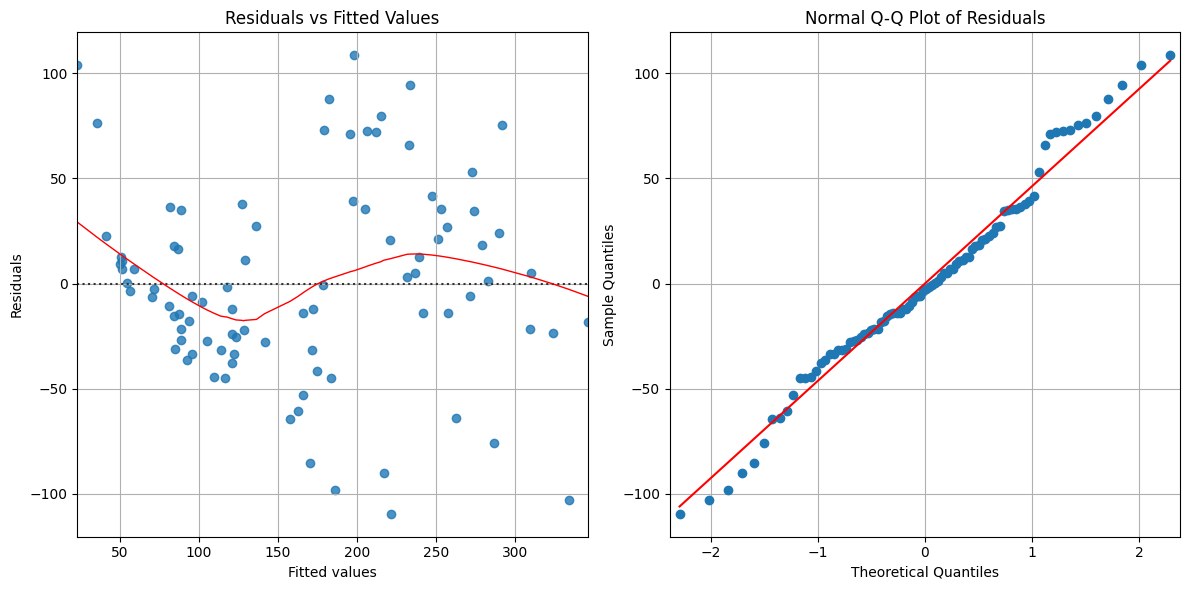

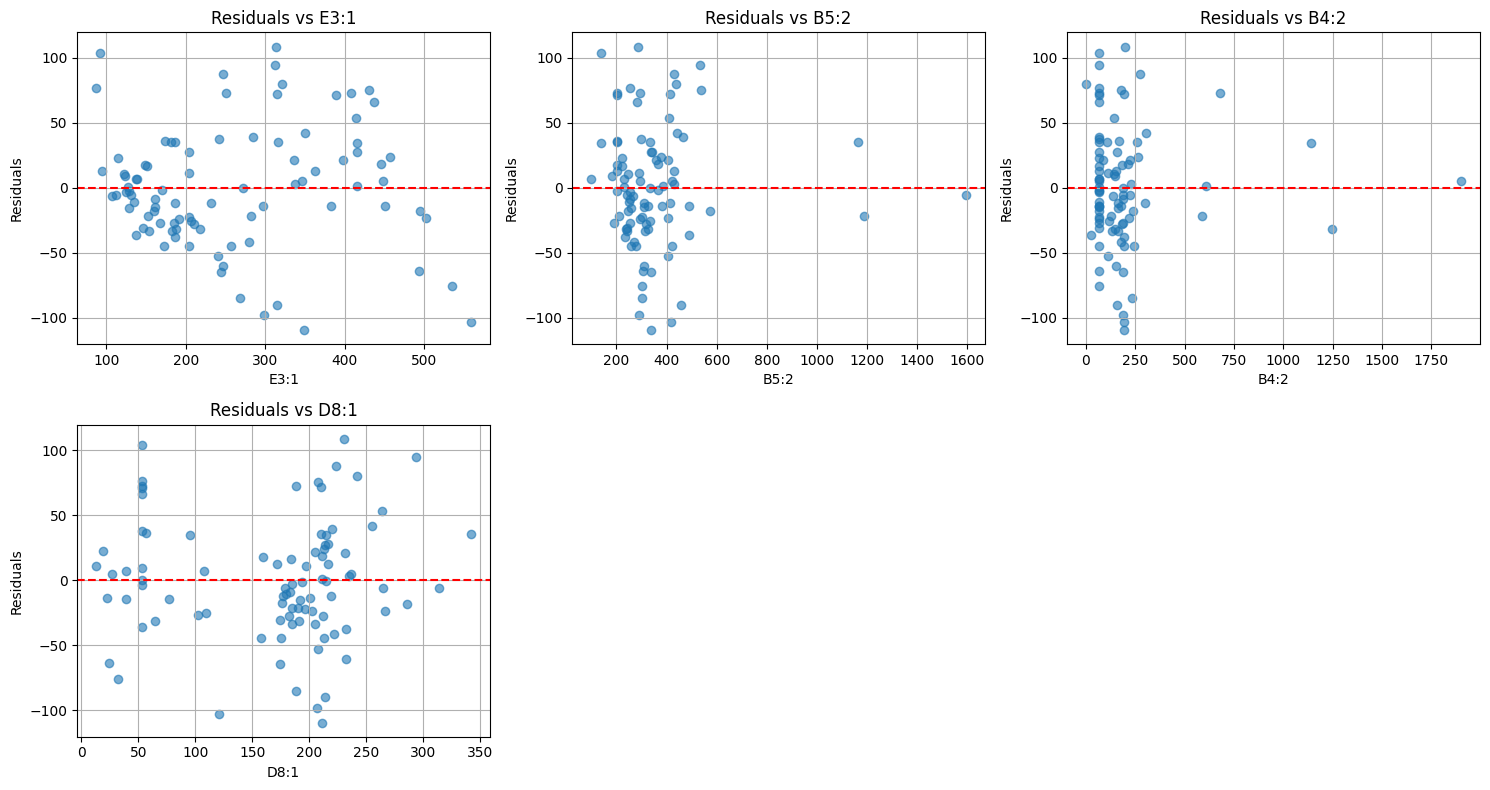

In [ ]:
# Residual diagnostics for the model including lagged variables

residuals = results_with_lags.resid
X_vars_with_lags = X_with_lags.drop(columns='const', errors='ignore')

# 1. Residuals vs fitted values and normal Q-Q plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.residplot(
    x=results_with_lags.fittedvalues,
    y=residuals,
    lowess=True,
    line_kws={'color': 'red', 'lw': 1}
)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Residuals against each selected explanatory variable
cols_per_row = 3
num_plots = len(X_vars_with_lags.columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(5 * cols_per_row, 4 * rows))

for i, col in enumerate(X_vars_with_lags.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.scatter(X_vars_with_lags[col], residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()


--- Assumptions checking on residuals ---

1. Normality:
   Shapiro-Wilk Test: Statistic=0.983, p-value=0.287
   (The p-value is greater than 0.05, we cannot reject the null hypothesis of normality.)

2. Independence (Absence of Autocorrelation):


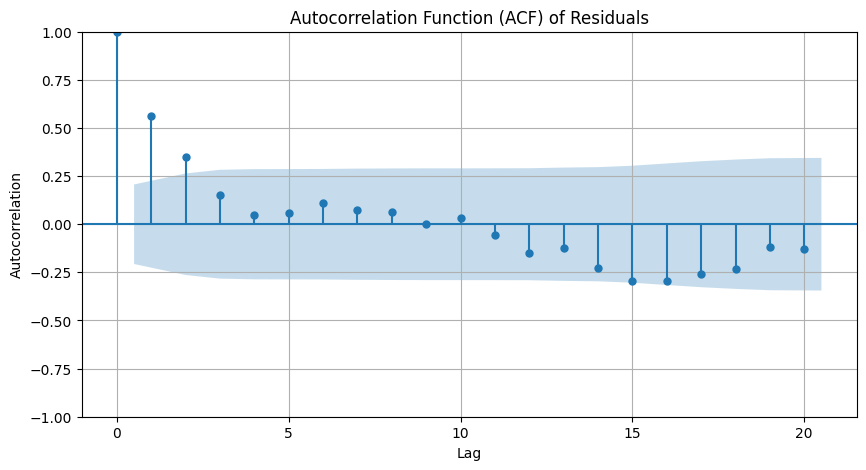

   Ljung-Box Test (p-values for lags 1, 5, 10):
 1     6.206096e-08
5     2.888506e-08
10    1.562386e-06
Name: lb_pvalue, dtype: float64
   (For lag 1, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)
   (For lag 5, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)
   (For lag 10, p-value 0.000 <= 0.05, the null hypothesis of no autocorrelation is rejected.)


In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

residuals = results_with_lags.resid

print("\n--- Assumptions checking on residuals ---")

# 1. Normality of Residuals
print("\n1. Normality:")
# Shapiro-Wilk Test (for small samples, N < 5000)
shapiro_test = stats.shapiro(residuals)
print(f"   Shapiro-Wilk Test: Statistic={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue > 0.05:
    print("   (The p-value is greater than 0.05, we cannot reject the null hypothesis of normality.)")
else:
    print("   (The p-value is less than 0.05, we reject the null hypothesis of normality.)")

# 2. Independence of Residuals (Absence of Autocorrelation)
print("\n2. Independence (Absence of Autocorrelation):")
# Autocorrelation Function (ACF) Plot
plt.figure(figsize=(10, 5))
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Ljung-Box Test
# The Ljung-Box test checks if autocorrelations for a time series are different from zero for a number of lags.
# 'lb_pvalue' is the p-value, 'lb_stat' is the test statistic.
ljungbox_test = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print("   Ljung-Box Test (p-values for lags 1, 5, 10):\n", ljungbox_test['lb_pvalue'])
for lag, pval in ljungbox_test['lb_pvalue'].items():
    if pval > 0.05:
        print(f"   (For lag {lag}, p-value {pval:.3f} > 0.05, no evidence of autocorrelation.)")
    else:
        print(f"   (For lag {lag}, p-value {pval:.3f} <= 0.05, the null hypothesis of no autocorrelation is rejected.)")

In [ ]:
# MAPE for Option 2 (Part A - Training Data)
y_A_observed_option2 = df_final_with_lags[dependent_variable]
y_A_forecast_option2 = results_with_lags.predict(X_with_lags)
mape_A_option2 = mean_absolute_percentage_error(y_A_observed_option2, y_A_forecast_option2)
print(f"Model 2 (Lagged) - Training Data: MAPE = {mape_A_option2:.2f}%")

Model 2 (Lagged) - Training Data: MAPE = 26.46%


# Part B

In [ ]:
# PART B — Evaluation on the independent dataset

# Select the evaluation period
df_B_eval = df.copy()
df_B_eval = df_B_eval[(df_B_eval['Day'] >= 18) & (df_B_eval['Day'] <= 21)]
df_B_eval = df_B_eval.drop(columns=['Year', 'Month'])

display(df_B_eval.head())
print(f"Original evaluation dataset shape: {df_B_eval.shape}")

# 1. Create 'Unique_Time_Period' and pivot the evaluation dataset

df_B_eval['Unique_Time_Period'] = (
    df_B_eval['Day'].astype(str) + '_' + df_B_eval['Time'].astype(str)
)

df_B_pivot = df_B_eval.pivot_table(
    index='Unique_Time_Period',
    columns='Route',
    values='Travel Time'
)

df_B_pivot = df_B_pivot.reset_index()
df_B_pivot.columns.name = None

# Keep NaNs at this stage, exactly as in Part A
df_B_base = df_B_pivot.copy()

# 2. Reconstruct Day and Time_seconds

df_B_base[['Day_str', 'Time_str']] = (
    df_B_base['Unique_Time_Period'].str.split('_', expand=True)
)

df_B_base['Day'] = df_B_base['Day_str'].astype(int)
df_B_base['Time_seconds'] = df_B_base['Time_str'].astype(int)

# 3. Create datetime exactly as in Part A

fixed_year_B = 2005
fixed_month_B = 4

df_B_base['datetime'] = (
    pd.to_datetime(f'{fixed_year_B}-{fixed_month_B}-01')
    + (df_B_base['Day'] - 1).astype('timedelta64[D]')
    + pd.to_timedelta(df_B_base['Time_seconds'], unit='s')
)

# Sort chronologically
df_B_base = (
    df_B_base
    .sort_values(by='datetime')
    .reset_index(drop=True)
)

print("Evaluation dataset after datetime construction and sorting:")
display(df_B_base.head())

# 4. Generate the same time-based lagged variables used in Part A

dependent_variable_B = 'D7:2'

# Identify the variables to lag using the same logic as Part A
candidates_for_lagging_B = [
    col for col in df_B_base.columns
    if col not in [
        'Unique_Time_Period',
        'datetime',
        'Day_str',
        'Time_str',
        'Day',
        'Time_seconds',
        dependent_variable_B
    ]
]

df_B_model_time_lagged = df_B_base.copy()

all_new_lagged_cols_B = []

# Only generate lag1 with fixed suffix '_lag1' as requested
lag_suffix_B = '_lag1'
lag_duration_B = pd.Timedelta(minutes=15) # Assuming a 15-minute interval for lag1

for col in candidates_for_lagging_B:
    new_col_name = f'{col}{lag_suffix_B}'

    # Create a temporary DataFrame with 'datetime' and the current variable 'col'
    lag_values_df_B = df_B_base[['datetime', col]].copy()

    # Create a 'lagged_timestamp' column in this temp_df
    lag_values_df_B['lagged_timestamp'] = lag_values_df_B['datetime'] + lag_duration_B

    # Rename the original column to the new lagged column name for the merge
    lag_values_df_B = lag_values_df_B.rename(columns={col: new_col_name})

    # Perform a left merge to attach the lagged value
    df_B_model_time_lagged = pd.merge(
        df_B_model_time_lagged,
        lag_values_df_B[['lagged_timestamp', new_col_name]],
        left_on='datetime',
        right_on='lagged_timestamp',
        how='left'
    )
    # Drop the temporary 'lagged_timestamp' column from the merged result
    df_B_model_time_lagged = df_B_model_time_lagged.drop(columns=['lagged_timestamp'])

    all_new_lagged_cols_B.append(new_col_name)

# 5. Final preparation of the evaluation dataset
#    Same preparation as Part A

columns_to_drop_B = [
    'Day_str',
    'Time_str',
    'Day',
    'Time_seconds',
    'datetime'
]

df_B_final_with_lags = df_B_model_time_lagged.drop(
    columns=columns_to_drop_B
)

full_independent_candidates_list_B = (
    candidates_for_lagging_B
    + all_new_lagged_cols_B
)

# Remove rows containing NaNs in the dependent variable
# or in any candidate explanatory variable
df_B_final_with_lags = df_B_final_with_lags.dropna(
    subset=[
        dependent_variable_B
    ] + full_independent_candidates_list_B
)

print(
    "Final evaluation dataset shape after "
    "adding lagged variables and removing NaNs:",
    df_B_final_with_lags.shape
)

display(df_B_final_with_lags.head(10))

,Route,Day,Time,Segment Length,Travel Time
940,E3:1,18,22635,1177,106
941,D8:1,18,22635,604,19
942,D7:2,18,22635,625,58
943,D6:2,18,22635,1329,177
944,B4:2,18,22635,997,73


Original evaluation dataset shape: (376, 5)
Evaluation dataset after datetime construction and sorting:


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,Day_str,Time_str,Day,Time_seconds,datetime
0,18_22635,73.0,NaN,177.0,58.0,19.0,NaN,106.0,18,22635,18,22635,2005-04-18 06:17:15
1,18_23535,146.0,201.0,187.0,21.0,36.0,121.0,147.0,18,23535,18,23535,2005-04-18 06:32:15
2,18_24435,103.0,201.0,144.0,24.0,53.0,127.0,127.0,18,24435,18,24435,2005-04-18 06:47:15
3,18_25335,172.0,207.0,144.0,52.0,2.0,69.0,154.0,18,25335,18,25335,2005-04-18 07:02:15
4,18_26235,103.0,172.0,183.0,35.0,19.0,101.0,162.0,18,26235,18,26235,2005-04-18 07:17:15


Final evaluation dataset shape after adding lagged variables and removing NaNs: (40, 14)


,Unique_Time_Period,B4:2,B5:2,D6:2,D7:2,D8:1,D8:2,E3:1,B4:2_lag1,B5:2_lag1,D6:2_lag1,D8:1_lag1,D8:2_lag1,E3:1_lag1
2,18_24435,103.0,201.0,144.0,24.0,53.0,127.0,127.0,146.0,201.0,187.0,36.0,121.0,147.0
3,18_25335,172.0,207.0,144.0,52.0,2.0,69.0,154.0,103.0,201.0,144.0,53.0,127.0,127.0
4,18_26235,103.0,172.0,183.0,35.0,19.0,101.0,162.0,172.0,207.0,144.0,2.0,69.0,154.0
5,18_27135,167.0,109.0,225.0,169.0,182.0,94.0,192.0,103.0,172.0,183.0,19.0,101.0,162.0
6,18_28035,190.0,97.0,186.0,215.0,264.0,119.0,209.0,167.0,109.0,225.0,182.0,94.0,192.0
7,18_28935,114.0,3.0,224.0,35.0,268.0,152.0,252.0,190.0,97.0,186.0,264.0,119.0,209.0
8,18_29835,68.0,169.0,300.0,317.0,235.0,135.0,450.0,114.0,3.0,224.0,268.0,152.0,252.0
9,18_30735,65.0,169.0,281.0,35.0,232.0,157.0,414.0,68.0,169.0,300.0,235.0,135.0,450.0
10,18_31635,65.0,169.0,205.0,35.0,317.0,138.0,481.0,65.0,169.0,281.0,232.0,157.0,414.0
11,18_32535,65.0,169.0,223.0,35.0,269.0,55.0,483.0,65.0,169.0,205.0,317.0,138.0,481.0



--- MAPE Calculation and other metrics for Models on Test Data (Part B) ---

Option 2 (Contemporaneous + Lagged Variables) - Test Data:
  R²   = 0.020
  RMSE = 122.43
  MAPE = 161.92%


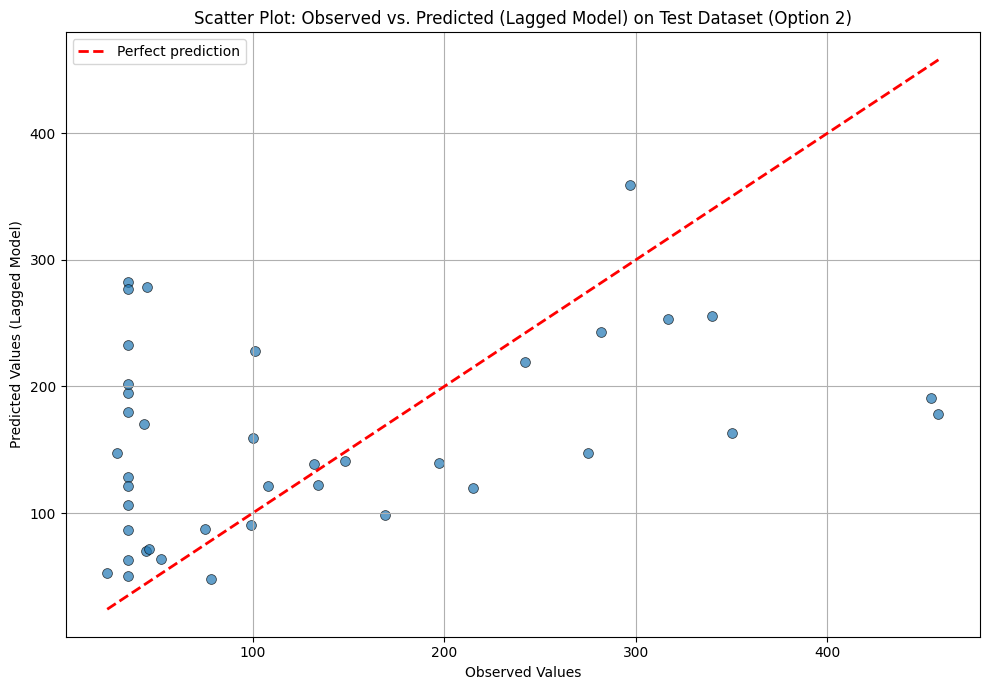

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# Observed target for Part B
y_B_observed = df_B_final_with_lags[dependent_variable_B]

# ---------------------------------------------------------
# OPTION 2 — Model with lagged variables (trained with 'results_with_lags')
# ---------------------------------------------------------

X_B_option2 = df_B_final_with_lags[selected_X_cols_with_lags]
X_B_option2 = sm.add_constant(X_B_option2, has_constant='add')

# Ensure X_B_option2 columns match the training X_with_lags columns order
X_B_option2 = X_B_option2[X_with_lags.columns]


y_B_forecast_option2 = results_with_lags.predict(X_B_option2)

# Calculate metrics for Option 2
r2_B_option2 = r2_score(y_B_observed, y_B_forecast_option2)
rmse_B_option2 = np.sqrt(mean_squared_error(y_B_observed, y_B_forecast_option2))

print("\n--- MAPE Calculation and other metrics for Models on Test Data (Part B) ---")

# For Option 2 (Part B - Test Data), R2 and RMSE are already calculated (r2_B_option2, rmse_B_option2)
# y_B_observed and y_B_forecast_option2 are already available.
mape_B_option2 = mean_absolute_percentage_error(y_B_observed, y_B_forecast_option2)

print("\nOption 2 (Contemporaneous + Lagged Variables) - Test Data:")
print(f"  R²   = {r2_B_option2:.3f}")
print(f"  RMSE = {rmse_B_option2:.2f}")
print(f"  MAPE = {mape_B_option2:.2f}%")

# Scatter plot for Option 2 (Part B)
plt.figure(figsize=(10, 7)) # Adjusted size for better visibility
sns.scatterplot(x=y_B_observed, y=y_B_forecast_option2, alpha=0.7, edgecolor='k', s=50)

# Add a line for perfect prediction
min_val = min(y_B_observed.min(), y_B_forecast_option2.min())
max_val = max(y_B_observed.max(), y_B_forecast_option2.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red', linewidth=2, label='Perfect prediction')

plt.xlabel('Observed Values')
plt.ylabel('Predicted Values (Lagged Model)')
plt.title('Scatter Plot: Observed vs. Predicted (Lagged Model) on Test Dataset (Option 2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The model produces very bad results especially for low observed values, this might be due to lack in independence and to eteroschedasticity, as well as few observations available (considering the nan and the rows with no 15min-before value. They may also be a not very representative sample. I would have modelled this as an ARIMA model.